# Weekly Internship Report - Week 2
**Intern:** Hetvi Patoliya (24AIML050)

## Task 7: Insights & Trends Analysis on Scraped Data

This notebook loads `scraped_books.csv` (produced in **Task 6**) and identifies key patterns, trends, and outliers, presenting the findings through charts.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [3]:
df = pd.read_csv("scraped_books.csv")
print("Shape:", df.shape)
df.info()


Shape: (300, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      300 non-null    object 
 1   price_gbp  300 non-null    float64
 2   rating     300 non-null    int64  
 3   in_stock   300 non-null    bool   
 4   category   300 non-null    object 
dtypes: bool(1), float64(1), int64(1), object(2)
memory usage: 9.8+ KB


In [4]:
df.describe(include="all")


,title,price_gbp,rating,in_stock,category
count,300,300.000000,300.000000,300,300
unique,300,NaN,NaN,1,40
top,A Light in the Attic,NaN,NaN,True,Default
freq,1,NaN,NaN,300,47
mean,NaN,34.262933,2.916667,NaN,NaN
std,NaN,14.102895,1.441057,NaN,NaN
min,NaN,10.160000,1.000000,NaN,NaN
25%,NaN,21.930000,2.000000,NaN,NaN
50%,NaN,35.520000,3.000000,NaN,NaN
75%,NaN,46.022500,4.000000,NaN,NaN


### Insight 1: Which categories have the most books listed?

C:\Users\Hetvi\AppData\Local\Temp\ipykernel_6916\1067491845.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette="viridis")


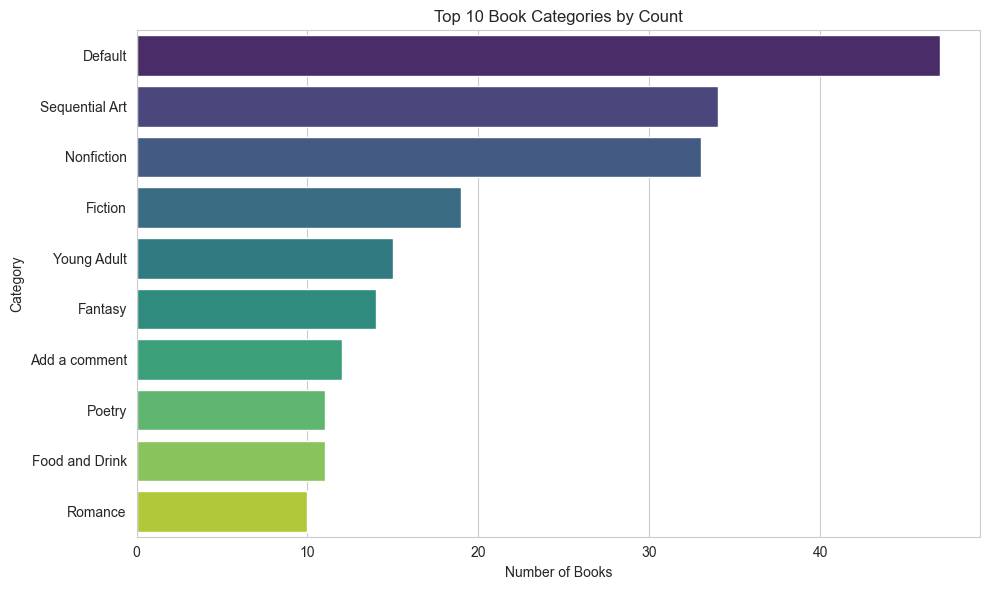

In [5]:
top_categories = df["category"].value_counts().head(10)

plt.figure()
sns.barplot(x=top_categories.values, y=top_categories.index, palette="viridis")
plt.title("Top 10 Book Categories by Count")
plt.xlabel("Number of Books")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("top_categories.png")
plt.show()


### Insight 2: Price distribution and outliers

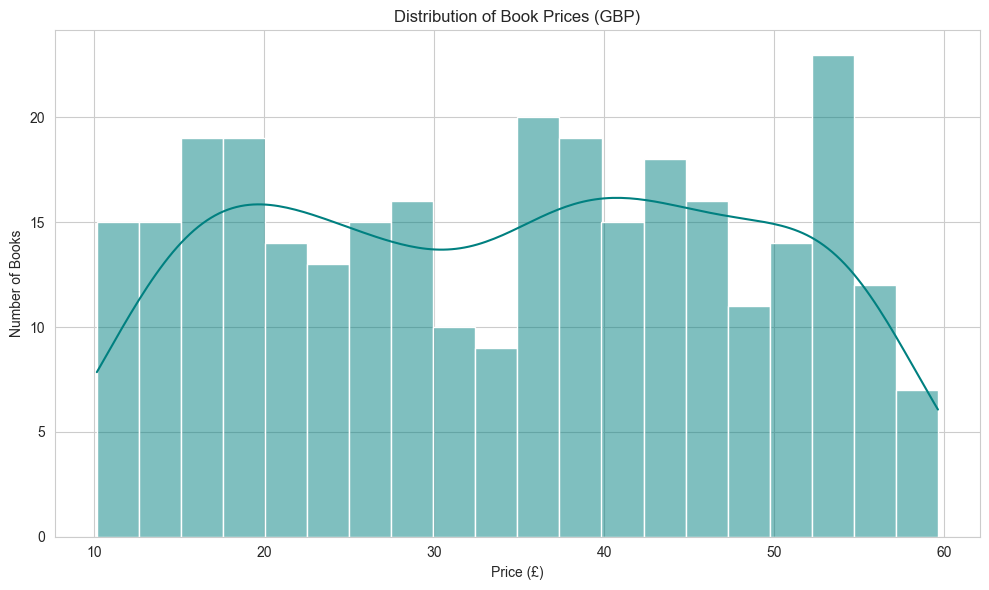

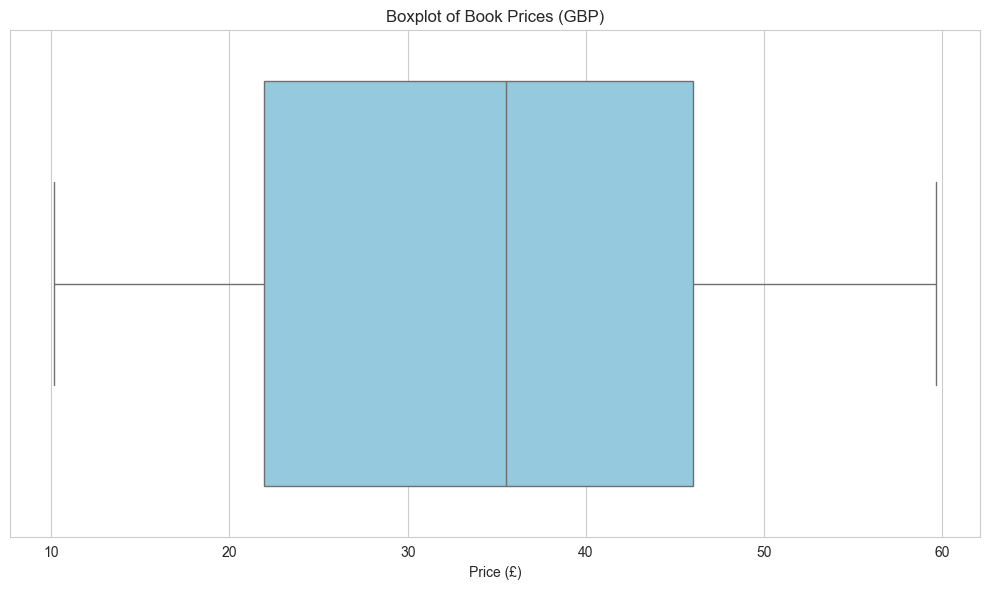

IQR bounds: [-14.21, 82.16]
Number of price outliers: 0


,title,price_gbp,category


In [ ]:
plt.figure()
sns.histplot(df["price_gbp"], bins=20, kde=True, color="teal")
plt.title("Distribution of Book Prices (GBP)")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.savefig("price_distribution.png")
plt.show()

plt.figure()
sns.boxplot(x=df["price_gbp"], color="skyblue")
plt.title("Boxplot of Book Prices (GBP)")
plt.xlabel("Price (£)")
plt.tight_layout()
plt.savefig("price_boxplot.png")
plt.show()

Q1, Q3 = df["price_gbp"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = df[(df["price_gbp"] < lower) | (df["price_gbp"] > upper)]
print(f"IQR bounds: [{lower:.2f}, {upper:.2f}]")
print(f"Number of price outliers: {len(outliers)}")
outliers[["title", "price_gbp", "category"]].head(10)


### Insight 3: Star rating trends

C:\Users\Hetvi\AppData\Local\Temp\ipykernel_6916\3627022310.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, palette="magma")


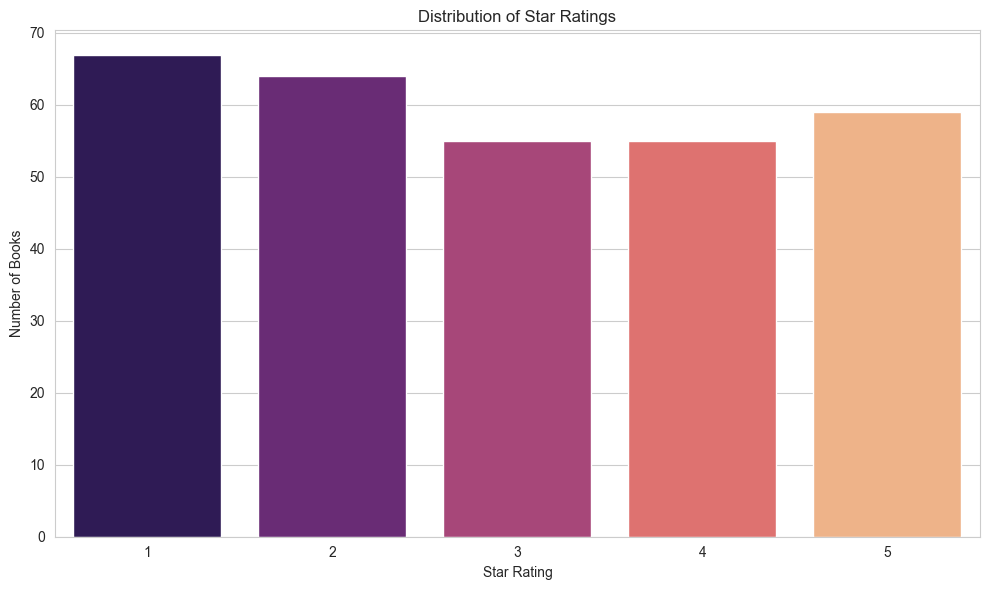

Average rating: 2.92


In [7]:
rating_counts = df["rating"].value_counts().sort_index()

plt.figure()
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette="magma")
plt.title("Distribution of Star Ratings")
plt.xlabel("Star Rating")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.savefig("rating_distribution.png")
plt.show()

print("Average rating:", round(df["rating"].mean(), 2))


### Insight 4: Does price vary with rating?

C:\Users\Hetvi\AppData\Local\Temp\ipykernel_6916\493759123.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="rating", y="price_gbp", data=df, palette="coolwarm")


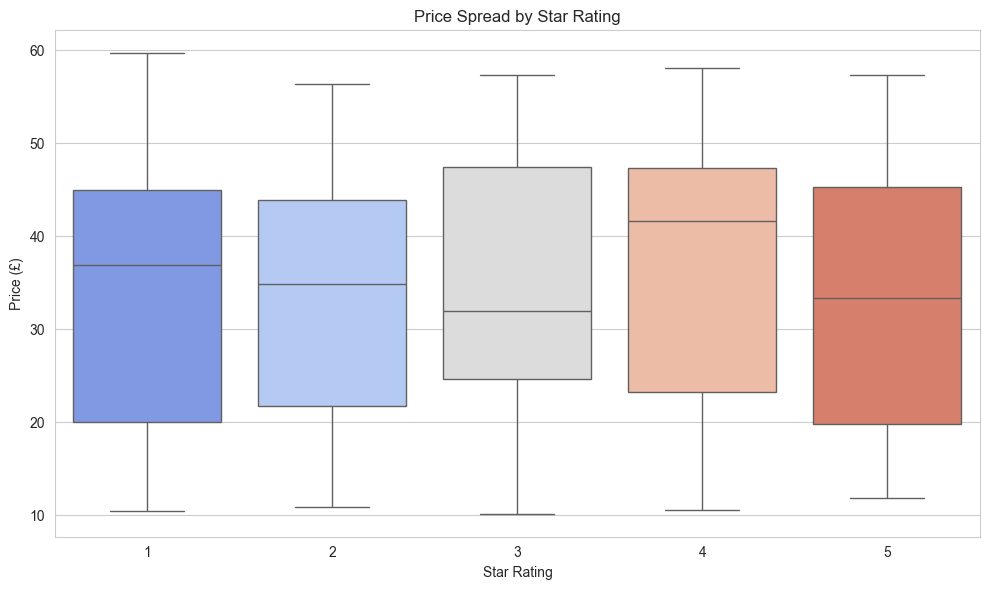

Average price by rating:
rating
1    33.87
2    32.96
3    34.75
4    37.02
5    33.09
Name: price_gbp, dtype: float64


In [8]:
plt.figure()
sns.boxplot(x="rating", y="price_gbp", data=df, palette="coolwarm")
plt.title("Price Spread by Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Price (£)")
plt.tight_layout()
plt.savefig("price_by_rating.png")
plt.show()

avg_price_by_rating = df.groupby("rating")["price_gbp"].mean().round(2)
print("Average price by rating:")
print(avg_price_by_rating)


### Insight 5: Stock availability

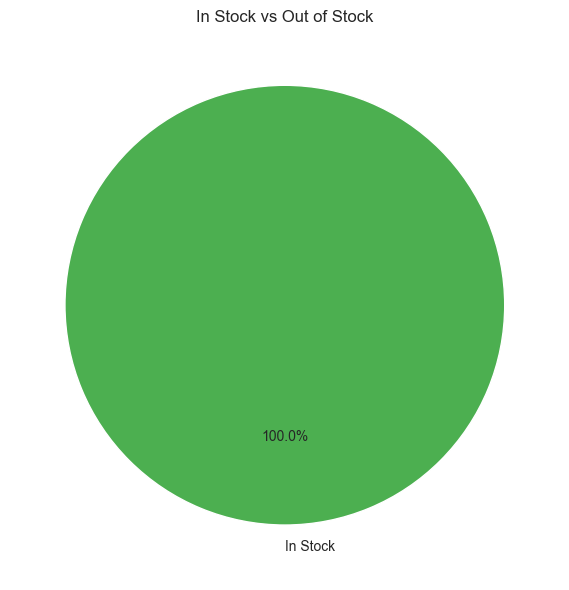

In [9]:
stock_counts = df["in_stock"].value_counts()

plt.figure()
plt.pie(stock_counts.values, labels=stock_counts.index.map({True: "In Stock", False: "Out of Stock"}),
        autopct="%1.1f%%", colors=["#4CAF50", "#F44336"], startangle=90)
plt.title("In Stock vs Out of Stock")
plt.tight_layout()
plt.savefig("stock_availability.png")
plt.show()


### Insight 6: Average price by category (top 10 most & least expensive)

C:\Users\Hetvi\AppData\Local\Temp\ipykernel_6916\3690633080.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_expensive["mean"], y=top_expensive.index, palette="rocket", ax=axes[0])
C:\Users\Hetvi\AppData\Local\Temp\ipykernel_6916\3690633080.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cheap["mean"], y=top_cheap.index, palette="crest", ax=axes[1])


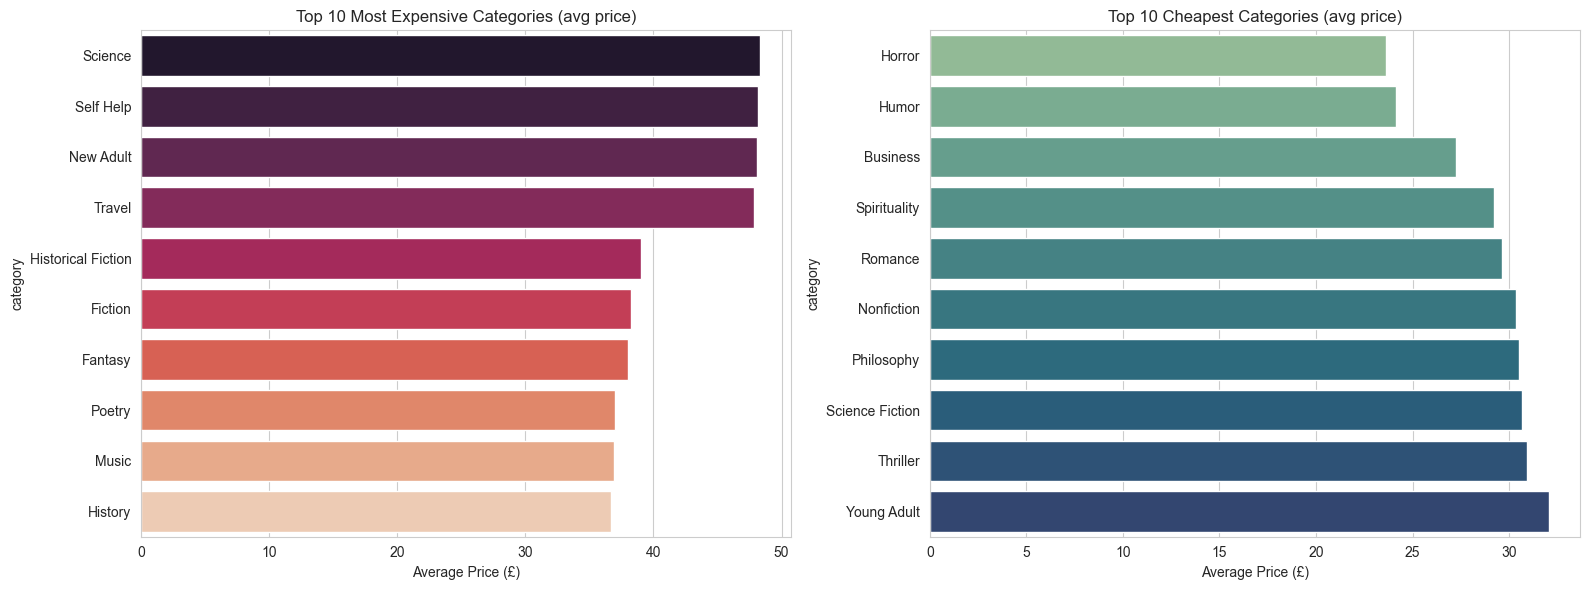

In [10]:
category_price = df.groupby("category")["price_gbp"].agg(["mean", "count"]).round(2)
category_price = category_price[category_price["count"] >= 3]  # ignore tiny categories

top_expensive = category_price.sort_values("mean", ascending=False).head(10)
top_cheap = category_price.sort_values("mean", ascending=True).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=top_expensive["mean"], y=top_expensive.index, palette="rocket", ax=axes[0])
axes[0].set_title("Top 10 Most Expensive Categories (avg price)")
axes[0].set_xlabel("Average Price (£)")

sns.barplot(x=top_cheap["mean"], y=top_cheap.index, palette="crest", ax=axes[1])
axes[1].set_title("Top 10 Cheapest Categories (avg price)")
axes[1].set_xlabel("Average Price (£)")

plt.tight_layout()
plt.savefig("category_price_extremes.png")
plt.show()


### Insight 7: Price variability within each category (spread, not just average)

C:\Users\Hetvi\AppData\Local\Temp\ipykernel_6916\1368968386.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=most_variable["std"], y=most_variable.index, palette="flare")


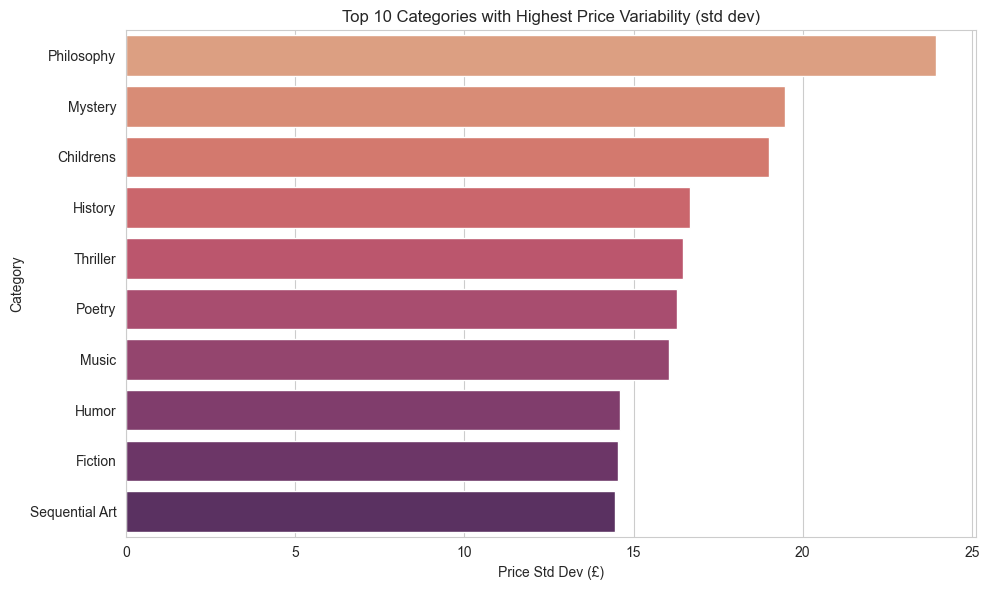

,mean,std,min,max,count,range
category,,,,,,
Philosophy,30.50,23.93,15.94,58.11,3,42.17
Mystery,32.94,19.47,10.69,56.50,8,45.81
Childrens,35.01,19.01,12.96,58.08,10,45.12
History,36.68,16.68,19.73,59.64,6,39.91
Thriller,30.92,16.45,12.84,52.22,6,39.38
Poetry,36.96,16.29,14.19,57.31,11,43.12
Music,36.90,16.06,18.03,57.25,4,39.22
Humor,24.16,14.61,11.83,44.07,4,32.24
Fiction,38.25,14.53,10.60,55.84,19,45.24


In [11]:
category_spread = df.groupby("category")["price_gbp"].agg(["mean", "std", "min", "max", "count"]).round(2)
category_spread = category_spread[category_spread["count"] >= 3]
category_spread["range"] = category_spread["max"] - category_spread["min"]
most_variable = category_spread.sort_values("std", ascending=False).head(10)

plt.figure()
sns.barplot(x=most_variable["std"], y=most_variable.index, palette="flare")
plt.title("Top 10 Categories with Highest Price Variability (std dev)")
plt.xlabel("Price Std Dev (£)")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("category_price_variability.png")
plt.show()

most_variable


### Insight 8: Top 10 most expensive & cheapest individual books

In [12]:
top10_expensive = df.nlargest(10, "price_gbp")[["title", "price_gbp", "rating", "category"]]
top10_cheap = df.nsmallest(10, "price_gbp")[["title", "price_gbp", "rating", "category"]]

print("Most expensive books:")
display(top10_expensive)

print("\nCheapest books:")
display(top10_cheap)


Most expensive books:


,title,price_gbp,rating,category
133,Thomas Jefferson and the Tripoli Pirates: The ...,59.64,1,History
68,The Death of Humanity: and the Case for Life,58.11,4,Philosophy
135,The White Cat and the Monk: A Retelling of the...,58.08,4,Childrens
100,Immunity: How Elie Metchnikoff Changed the Cou...,57.36,5,Science
186,I Had a Nice Time And Other Lies...: How to fi...,57.36,4,Womens Fiction
40,Slow States of Collapse: Poems,57.31,3,Poetry
15,Our Band Could Be Your Life: Scenes from the A...,57.25,3,Music
231,The Wright Brothers,56.80,4,Default
122,"A Piece of Sky, a Grain of Rice: A Memoir in F...",56.76,5,Default
58,The Past Never Ends,56.50,4,Mystery



Cheapest books:


,title,price_gbp,rating,category
84,Patience,10.16,3,Sequential Art
242,The Lucifer Effect: Understanding How Good Peo...,10.40,1,Psychology
274,Pet Sematary,10.56,3,Horror
297,I Am Pilgrim (Pilgrim #1),10.60,4,Fiction
144,The Project,10.65,1,Science Fiction
258,Tastes Like Fear (DI Marnie Rome #3),10.69,1,Mystery
181,Miss Peregrineâs Home for Peculiar Children ...,10.76,1,Default
163,The Argonauts,10.93,2,Autobiography
152,The Long Shadow of Small Ghosts: Murder and Me...,10.97,1,Crime
206,Beauty Restored (Riley Family Legacy Novellas #3),11.11,2,Default


### Insight 9: Correlation between price, rating, and stock status

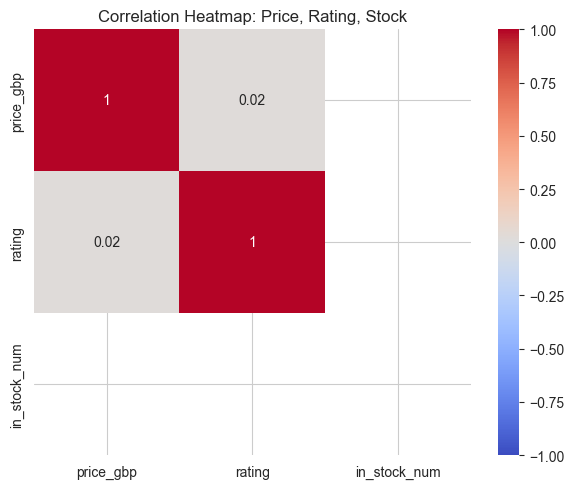

,price_gbp,rating,in_stock_num
price_gbp,1.00,0.02,NaN
rating,0.02,1.00,NaN
in_stock_num,NaN,NaN,NaN


In [13]:
corr_df = df.copy()
corr_df["in_stock_num"] = corr_df["in_stock"].astype(int)
corr_matrix = corr_df[["price_gbp", "rating", "in_stock_num"]].corr().round(2)

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap: Price, Rating, Stock")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()

corr_matrix


### Insight 10: Category vs. average rating (which genres rate highest?)

C:\Users\Hetvi\AppData\Local\Temp\ipykernel_6916\45490949.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_rated_categories["mean"], y=top_rated_categories.index, palette="viridis")


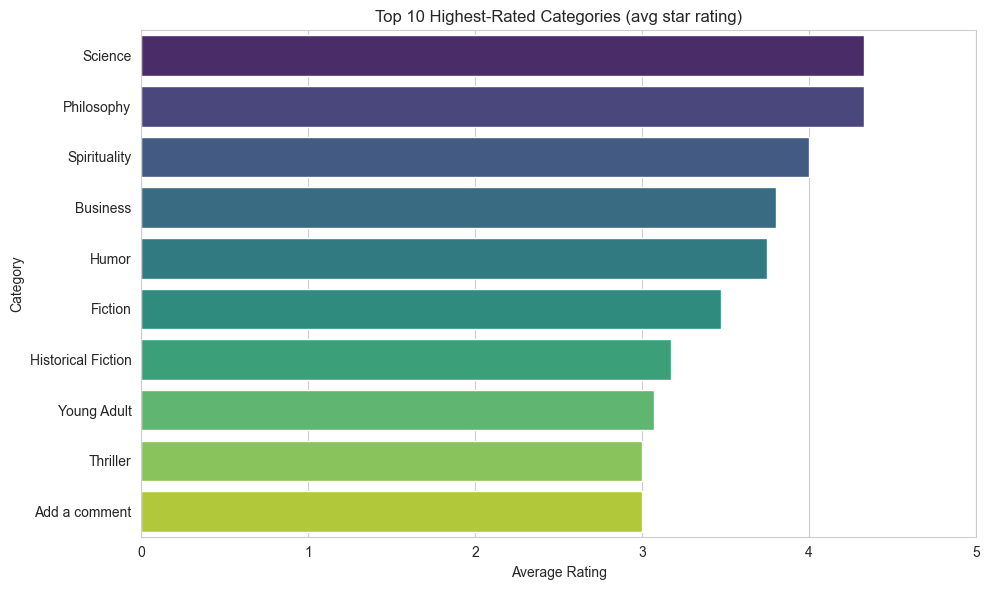

In [14]:
category_rating = df.groupby("category")["rating"].agg(["mean", "count"]).round(2)
category_rating = category_rating[category_rating["count"] >= 3]
top_rated_categories = category_rating.sort_values("mean", ascending=False).head(10)

plt.figure()
sns.barplot(x=top_rated_categories["mean"], y=top_rated_categories.index, palette="viridis")
plt.title("Top 10 Highest-Rated Categories (avg star rating)")
plt.xlabel("Average Rating")
plt.ylabel("Category")
plt.xlim(0, 5)
plt.tight_layout()
plt.savefig("category_avg_rating.png")
plt.show()


### Insight 11: Most common words in book titles (quick text trend check)

C:\Users\Hetvi\AppData\Local\Temp\ipykernel_6916\1336276121.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=word_df["count"], y=word_df["word"], palette="mako")


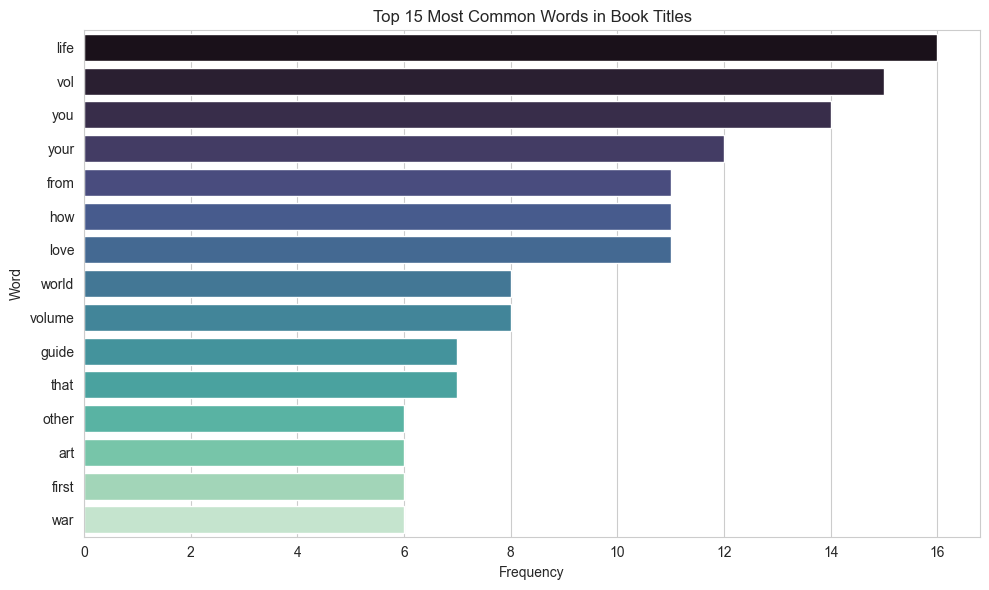

In [15]:
from collections import Counter
import re as re_mod

stopwords = {"the", "a", "an", "of", "and", "to", "in", "for", "on", "with", "&", "-", "is", "at", "by"}
words = []
for title in df["title"]:
    tokens = re_mod.findall(r"[a-zA-Z]+", title.lower())
    words.extend([t for t in tokens if t not in stopwords and len(t) > 2])

word_freq = Counter(words).most_common(15)
word_df = pd.DataFrame(word_freq, columns=["word", "count"])

plt.figure()
sns.barplot(x=word_df["count"], y=word_df["word"], palette="mako")
plt.title("Top 15 Most Common Words in Book Titles")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.savefig("title_word_frequency.png")
plt.show()


### Insight 12: Are higher-priced books more/less likely to be in stock?

C:\Users\Hetvi\AppData\Local\Temp\ipykernel_6916\1294017272.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="in_stock", y="price_gbp", data=df, palette="Set2")


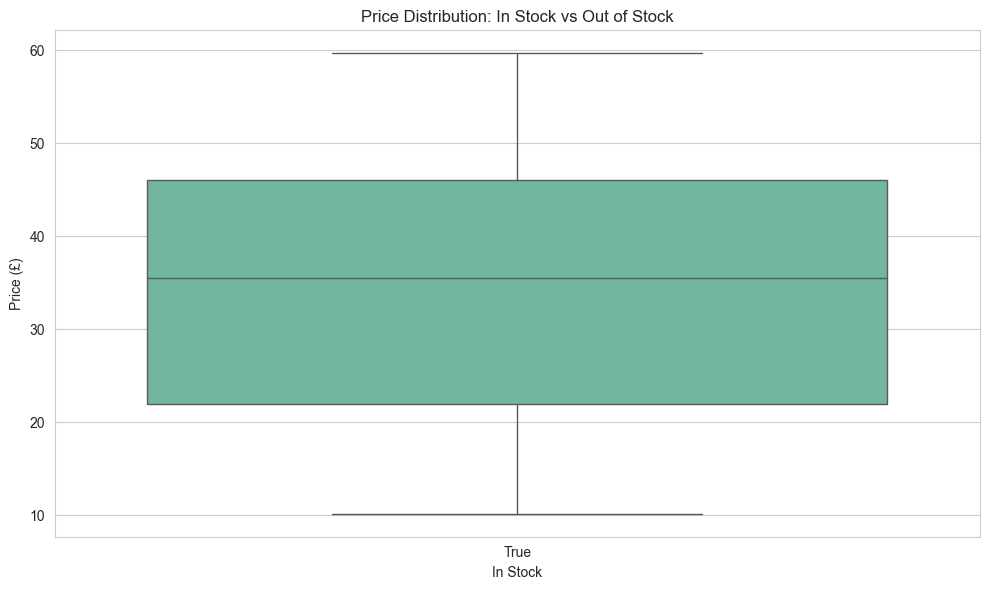

In [16]:
plt.figure()
sns.boxplot(x="in_stock", y="price_gbp", data=df, palette="Set2")
plt.title("Price Distribution: In Stock vs Out of Stock")
plt.xlabel("In Stock")
plt.ylabel("Price (£)")
plt.tight_layout()
plt.savefig("price_by_stock.png")
plt.show()


### Summary of Findings
- **Category concentration**: A handful of categories account for a disproportionate share of the catalogue (Insight 1), indicating where inventory is concentrated.
- **Price patterns**: Prices are right-skewed with IQR-flagged outliers (Insight 2); certain categories run consistently more expensive or cheaper on average (Insight 6), and some categories show far more price variability than others (Insight 7).
- **Extremes**: The most expensive and cheapest individual books highlight pricing extremes worth spot-checking (Insight 8).
- **Correlations**: Price, rating, and stock status show only weak correlation with each other (Insight 9) — rating and price appear largely independent, meaning higher price does not reliably signal a better-rated book.
- **Ratings by genre**: Certain categories skew toward higher average ratings than others (Insight 10).
- **Title text trends**: Common recurring words in titles hint at popular themes/genres in the catalogue (Insight 11).
- **Stock vs price**: Stock status shows little to no systematic price difference (Insight 12), suggesting availability isn't price-driven here.

These steps mirror a typical exploratory data analysis (EDA) workflow: load → profile → visualize → correlate → flag outliers → summarize.